In [378]:
#!pip install selenium
#!pip install dotenv
!pip install beautifulsoup4

In [379]:
import os #manipulando documentos do diretorio (.env)
from dotenv import load_dotenv #carrega a .env
from selenium import webdriver #driver do seleniu
from selenium.webdriver import ActionChains #Para executar click e escrita como mouse e teclado
from selenium.webdriver.common.by import By #Para identificar os tipos de elementos
from selenium.webdriver.support.ui import WebDriverWait #para criar o tempo de espera para interacoes
from selenium.webdriver.support import expected_conditions as EC #condicao de espera para a interacao

from bs4 import BeautifulSoup

In [380]:
#Carrega variaveis secretas
load_dotenv()

#Armazena variaveis secretas
usuario = os.getenv("USER_NAME")
password = os.getenv("USER_PASSWORD")

In [381]:
#Acessa o site RHonline pelo chrome
driver = webdriver.Chrome()
driver.get("https://rhonline.msgas.com.br/#/login")

#CRIANDO ACTION PARA PREENCHER CAMPOS E CLICAR
#site precisa do action para funcionar pois utilizando o driver puro nao foi capaz de escrever
#   estava retornando erro: ElementNotInteractableException
action = ActionChains(driver)

#UTILIZA METODO EXPLICIT WAIT
wait = WebDriverWait(driver, 10)#5 segundos de espera

In [382]:
#--------------------------
#
#   LOGIN NA PAGINA
#
#--------------------------

In [383]:
#identificacao dos campos de interacao
txtUser = wait.until(EC.element_to_be_clickable((By.NAME, "user"))) #campo do usuario
txtPassword = wait.until(EC.element_to_be_clickable((By.NAME, "password"))) #campo de senha
btnEntrar = wait.until(EC.visibility_of_element_located((By.TAG_NAME, "button")))

#Escreve o usuario e senha
action.move_to_element(txtUser).click().send_keys(usuario).perform()
action.move_to_element(txtPassword).click().send_keys(password).perform()

#clica em login
btnEntrar.click()

In [384]:
#--------------------------------------
#
#       Navega ate pagina de pontos
#
#--------------------------------------

In [385]:
#NAVEGAR PARA PAGINA DE PONTO
#   "botao" para clicar-> <span _ngcontent-ng-c3029837786="" aria-label="Acessar menu:  Ponto" class="an an-clock"></span>
ponto = wait.until(EC.element_to_be_clickable((By.XPATH, "//span[contains(@aria-label, 'Ponto')]")))
ponto.click()

#NAVEGA PARA O ESPELHO DE PONTO
#   "botao" para clicar -> <p _ngcontent-ng-c298496229=""> Espelho de ponto </p>
espelho = wait.until(EC.element_to_be_clickable((By.XPATH, "//p[contains(text(), 'Espelho de ponto')]")))
espelho.click()

In [386]:
#----------------------------------------------------------------
#
#   Extrai os dados dos pontos (daquele periodo)
#       (mas para esse teste utilizarei o periodo anterior)
#
#---------------------------------------------------------------

In [387]:
#!!!!!!!!!!aba para ser deletada, apenas para o teste anterior!!!!!!!!!

# opcao para clicar-> <option value="{&quot;initDate&quot;:&quot;2026-04-16T12:00:00Z&quot;,&quot;endDate&quot;:&quot;2026-05-15T12:00:00Z&quot;,&quot;actualPeriod&quot;:true,&quot;id&quot;:&quot;&quot;}"> 16/04/2026 - 15/05/2026 </option>
data_analisada = wait.until(EC.element_to_be_clickable((By.XPATH, "//option[contains(text(), '16/03/2026')]")))
data_analisada.click()

In [388]:
#HORA DO SHOWWW BEATIFULLSOAPPPP
page = driver.page_source
soup = BeautifulSoup(page, 'html.parser')
driver.quit() #nao sera mais necessario navegacao

<html class="new-light-AAA" data-a11y="AAA" data-beasties-container="" lang="pt"><head><style id="baseStyle">
      :root {
        
        --font-family: Roboto; --font-family-theme: Roboto; --font-family-theme-bold: Roboto-Bold; --font-family-theme-extra-light: Roboto-Condensed-Light; --font-family-heading: Roboto; --font-family-code: Monospace;
      }
    
      :root[class$="-AA"] {
        
        --outline-width: var(--border-width-md); --outline-width-focus-visible: var(--border-width-md);
      }
    
      :root[class*="-light"] {
        
        --color-caption-categorical-01: #004CFF; --color-caption-categorical-02: #C25534; --color-caption-categorical-03: #792CC7; --color-caption-categorical-04: #008768; --color-caption-categorical-05: #D62793; --color-caption-categorical-06: #D44317; --color-caption-categorical-07: #4779A8; --color-caption-categorical-08: #AD6207; --color-caption-categorical-overlay-01: #739CFD; --color-caption-categorical-overlay-02: #F6B5A1; --color-
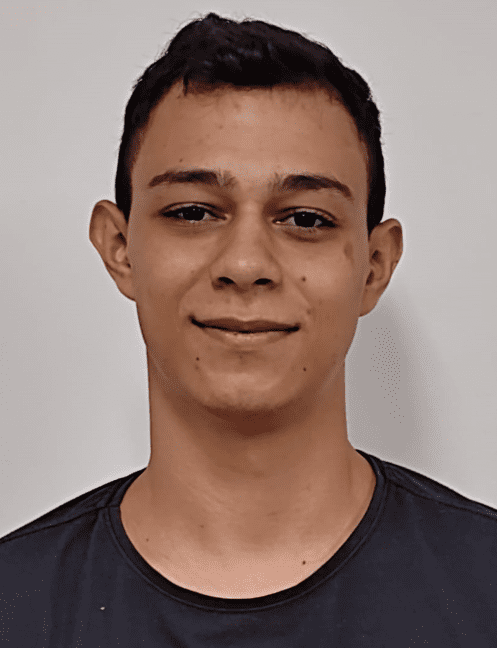

In [389]:
soup

In [390]:
#fecha o driver
#driver.quit()